# Credit Risk Default Prediction System

## Problem Statement

Financial institutions face significant losses due to loan defaults.

The objective of this project is to predict whether a customer will default within the next 12 months using historical credit behavior, loan information, payment history, and credit bureau data.

This project uses Machine Learning techniques such as Logistic Regression, Random Forest, and XGBoost to identify high-risk customers and support loan approval decisions.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Data Understanding

The objective of this section is to understand the structure of the datasets, identify missing values, verify data quality, and prepare the data for further analysis.


In [4]:
app = pd.read_csv("data/application.csv")
bureau = pd.read_csv("data/bureau.csv")
previous = pd.read_csv("data/previous_loans.csv")
payments = pd.read_csv("data/payments.csv")
credit = pd.read_csv("data/credit_card.csv")
labels = pd.read_csv("data/train_labels.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
df = app.merge(bureau, on="id")

df = df.merge(previous, on="id")

df = df.merge(payments, on="id")

df = df.merge(credit, on="id")

df = df.merge(labels, on="id")

print(df.shape)

(5000, 31)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify patterns, detect anomalies, and analyze factors that may influence loan default behavior.

The analysis includes:

* Dataset dimensions
* Missing value analysis
* Duplicate record analysis
* Statistical summaries
* Target variable distribution
* Feature distributions


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     5000 non-null   int64  
 1   age                    5000 non-null   int64  
 2   gender                 5000 non-null   str    
 3   education              5000 non-null   str    
 4   employment_type        5000 non-null   str    
 5   annual_income          5000 non-null   int64  
 6   loan_amount            5000 non-null   int64  
 7   loan_term              5000 non-null   int64  
 8   purpose                5000 non-null   str    
 9   home_ownership         5000 non-null   str    
 10  dependents             5000 non-null   int64  
 11  bureau_score           5000 non-null   int64  
 12  num_of_accounts        5000 non-null   int64  
 13  num_of_open_accounts   5000 non-null   int64  
 14  total_debt             5000 non-null   int64  
 15  delinquent_acco

In [7]:
df.describe()

,id,age,annual_income,loan_amount,loan_term,dependents,bureau_score,num_of_accounts,num_of_open_accounts,total_debt,...,avg_dpd,months_on_book,dpd,payment_amount,num_cards,credit_limit,utilization_ratio,max_utilization_ratio,late_payments,default_12m
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,42.575000,135304.463000,77096.643800,36.760800,2.535000,599.950800,5.985000,4.005400,100930.706800,...,44.230400,29.886800,60.074800,7776.991600,2.513400,155610.32080,0.519159,0.595806,5.430400,0.20000
std,1443.520003,12.554597,66880.056044,42066.342862,17.155339,1.724346,173.050067,3.132146,2.002142,57566.602912,...,25.979367,16.915011,34.719175,4177.135666,1.116096,83583.86881,0.277561,0.229792,3.489813,0.40004
min,1.000000,21.000000,20018.000000,5016.000000,12.000000,0.000000,300.000000,1.000000,1.000000,1005.000000,...,0.000000,1.000000,0.000000,501.000000,1.000000,10055.00000,0.050096,0.200112,0.000000,0.00000
25%,1250.750000,32.000000,76917.750000,39637.250000,24.000000,1.000000,449.000000,3.000000,2.000000,51177.500000,...,22.000000,15.000000,30.000000,4132.750000,2.000000,83796.50000,0.276841,0.393660,2.000000,0.00000
50%,2500.500000,43.000000,135100.500000,77974.500000,36.000000,3.000000,597.000000,6.000000,4.000000,101116.500000,...,44.000000,30.000000,61.000000,7754.000000,3.000000,157119.00000,0.518478,0.599607,5.000000,0.00000
75%,3750.250000,53.000000,193238.750000,113055.000000,48.000000,4.000000,749.250000,9.000000,6.000000,150133.750000,...,66.000000,45.000000,90.000000,11414.000000,4.000000,226977.50000,0.760214,0.792846,8.000000,0.00000
max,5000.000000,64.000000,249989.000000,149973.000000,60.000000,5.000000,899.000000,11.000000,7.000000,199990.000000,...,89.000000,59.000000,119.000000,14998.000000,4.000000,299838.00000,0.999992,0.999981,11.000000,1.00000


In [8]:
df.isnull().sum()

id                       0
age                      0
gender                   0
education                0
employment_type          0
annual_income            0
loan_amount              0
loan_term                0
purpose                  0
home_ownership           0
dependents               0
bureau_score             0
num_of_accounts          0
num_of_open_accounts     0
total_debt               0
delinquent_accounts      0
num_loans                0
num_defaults             0
total_loan_amount        0
total_repaid_amount      0
avg_dpd                  0
months_on_book           0
status                   0
dpd                      0
payment_amount           0
num_cards                0
credit_limit             0
utilization_ratio        0
max_utilization_ratio    0
late_payments            0
default_12m              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["default_12m"].value_counts()

default_12m
0    4000
1    1000
Name: count, dtype: int64

In [11]:
df["debt_to_income"] = (
    df["total_debt"] /
    df["annual_income"]
)

df["loan_to_income"] = (
    df["loan_amount"] /
    df["annual_income"]
)

df["repayment_ratio"] = (
    df["total_repaid_amount"] /
    df["total_loan_amount"]
)

df["credit_used"] = (
    df["credit_limit"] *
    df["utilization_ratio"]
)

print(df.shape)

(5000, 35)


## Data Visualization

Visualizations help understand customer characteristics and identify important trends associated with credit default risk.

The following charts are used to analyze:

* Default distribution
* Income distribution
* Credit score distribution
* Correlation among features


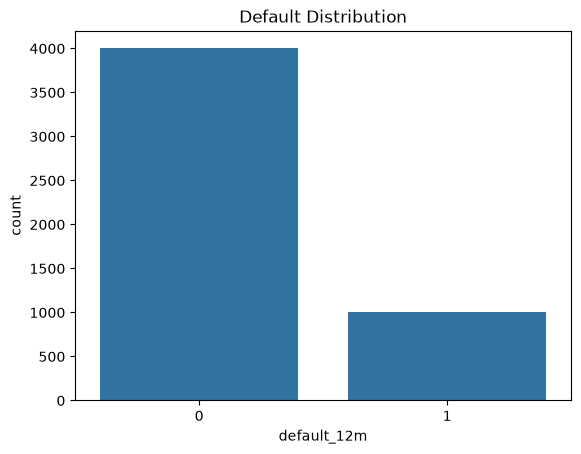

In [12]:
sns.countplot(x="default_12m", data=df)
plt.title("Default Distribution")
plt.show()

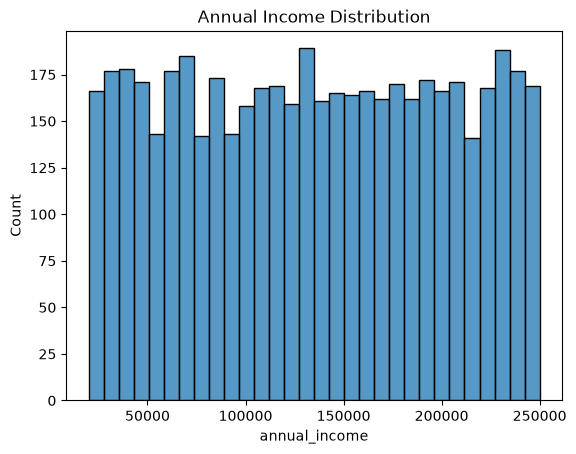

In [13]:
sns.histplot(df["annual_income"], bins=30)
plt.title("Annual Income Distribution")
plt.show()

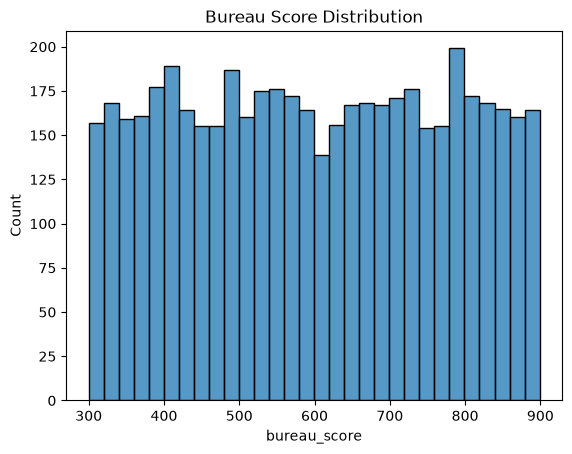

In [14]:
sns.histplot(df["bureau_score"], bins=30)
plt.title("Bureau Score Distribution")
plt.show()

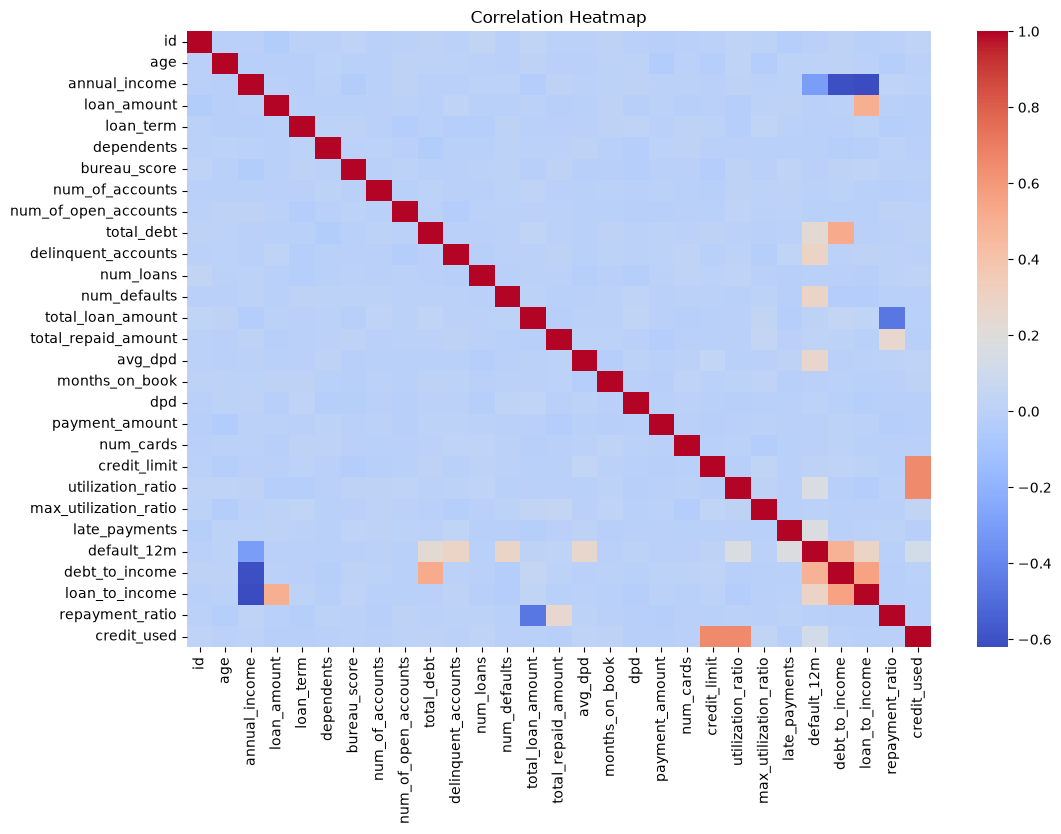

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

Feature Engineering is performed to create meaningful variables that better represent customer financial behavior.

The following features are generated:

* Debt-to-Income Ratio
* Loan-to-Income Ratio
* Repayment Ratio
* Credit Used

These engineered features help improve model performance and enhance prediction accuracy.


In [16]:
df["debt_to_income"] = (
    df["total_debt"] /
    df["annual_income"]
)

df["loan_to_income"] = (
    df["loan_amount"] /
    df["annual_income"]
)

df["repayment_ratio"] = (
    df["total_repaid_amount"] /
    df["total_loan_amount"]
)

df["credit_used"] = (
    df["credit_limit"] *
    df["utilization_ratio"]
)

print(df.shape)

(5000, 35)


In [17]:
df[[
    "debt_to_income",
    "loan_to_income",
    "repayment_ratio",
    "credit_used"
]].head()

,debt_to_income,loan_to_income,repayment_ratio,credit_used
0,1.928600,1.394747,1.561493,47917.209011
1,1.023590,1.422650,0.484568,81589.638503
2,0.785150,0.808024,0.239609,98545.784413
3,0.121028,0.350348,2.302143,61833.460719
4,0.815808,0.436141,1.086818,78583.699433


# Data Preprocessing

Before model training, the dataset is prepared using the following preprocessing steps:

* Handling categorical variables using One-Hot Encoding
* Feature selection
* Train-Test Split
* Class balancing using SMOTE

These steps ensure that the machine learning models can effectively learn from the data.


In [18]:
categorical_cols = [
    "gender",
    "education",
    "employment_type",
    "purpose",
    "home_ownership",
    "status"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df.shape)

(5000, 42)


In [19]:
X = df.drop(
    ["default_12m"],
    axis=1
)

y = df["default_12m"]

print(X.shape)
print(y.shape)

(5000, 41)
(5000,)


## Train-Test Split

The dataset is divided into training and testing sets.

* Training Data: 80%
* Testing Data: 20%

This allows unbiased evaluation of model performance on unseen data.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 41)
(1000, 41)


## Handling Class Imbalance using SMOTE

The target variable is imbalanced because default cases are significantly fewer than non-default cases.

SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the classes and improve model learning.


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

default_12m
0    3200
1    3200
Name: count, dtype: int64


# Machine Learning Model Development

Three machine learning algorithms are trained and evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

The objective is to identify the model that best predicts customer loan default risk.


## Logistic Regression

Logistic Regression serves as the baseline model for binary classification.

It predicts the probability that a customer will default within the next 12 months.


In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

c:\Users\Vikhila K\Desktop\Credit_Risk_Default_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.758
Precision: 0.4396551724137931
Recall   : 0.765
F1 Score : 0.5583941605839416


## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It captures non-linear relationships and improves predictive performance compared to the baseline model.


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

### Random Forest Evaluation

The Random Forest model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The results are compared with the baseline Logistic Regression model.


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.911
Precision: 0.7846153846153846
Recall   : 0.765
F1 Score : 0.7746835443037975
ROC AUC : 0.95331875


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
24,debt_to_income,0.148624
15,avg_dpd,0.097943
2,annual_income,0.084848
12,num_defaults,0.068556
10,delinquent_accounts,0.062683
9,total_debt,0.052307
21,utilization_ratio,0.047189
25,loan_to_income,0.044495
23,late_payments,0.037670
27,credit_used,0.025368


## XGBoost

XGBoost is a powerful gradient boosting algorithm widely used in credit risk modeling.

It is expected to provide the highest predictive accuracy by effectively handling complex feature interactions.


In [27]:
from xgboost import XGBClassifier

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

### XGBoost Evaluation

The XGBoost model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. This model achieved the best overall performance and was selected as the final model.


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.936
Precision: 0.8300970873786407
Recall   : 0.855
F1 Score : 0.8423645320197044
ROC AUC : 0.9828125


# Model Comparison

The performance of Logistic Regression, Random Forest, and XGBoost is compared using multiple evaluation metrics.

Among all models, XGBoost achieved the highest Accuracy, F1 Score, and ROC-AUC, making it the most suitable model for credit risk prediction.


# Cross Validation

Cross Validation is performed to evaluate the stability and robustness of the selected model.

The dataset is divided into multiple folds, and the model is trained and tested repeatedly. The average F1 Score is used as the final validation metric.


In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print(scores)
print("Average F1:", scores.mean())

[0.88962656 0.95846154 0.95619335 0.96436694 0.96352584]
Average F1: 0.9464348456947519


# Feature Importance Analysis

Feature Importance analysis helps identify which variables contribute most to loan default prediction.

Understanding important risk factors improves model transparency and supports business decision-making.


In [31]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
24,debt_to_income,0.148624
15,avg_dpd,0.097943
2,annual_income,0.084848
12,num_defaults,0.068556
10,delinquent_accounts,0.062683
9,total_debt,0.052307
21,utilization_ratio,0.047189
25,loan_to_income,0.044495
23,late_payments,0.037670
27,credit_used,0.025368


In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
import shap

In [34]:
import streamlit as st

In [36]:
import joblib

joblib.dump(
    xgb,
    "data/models/credit_risk_xgboost.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [37]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

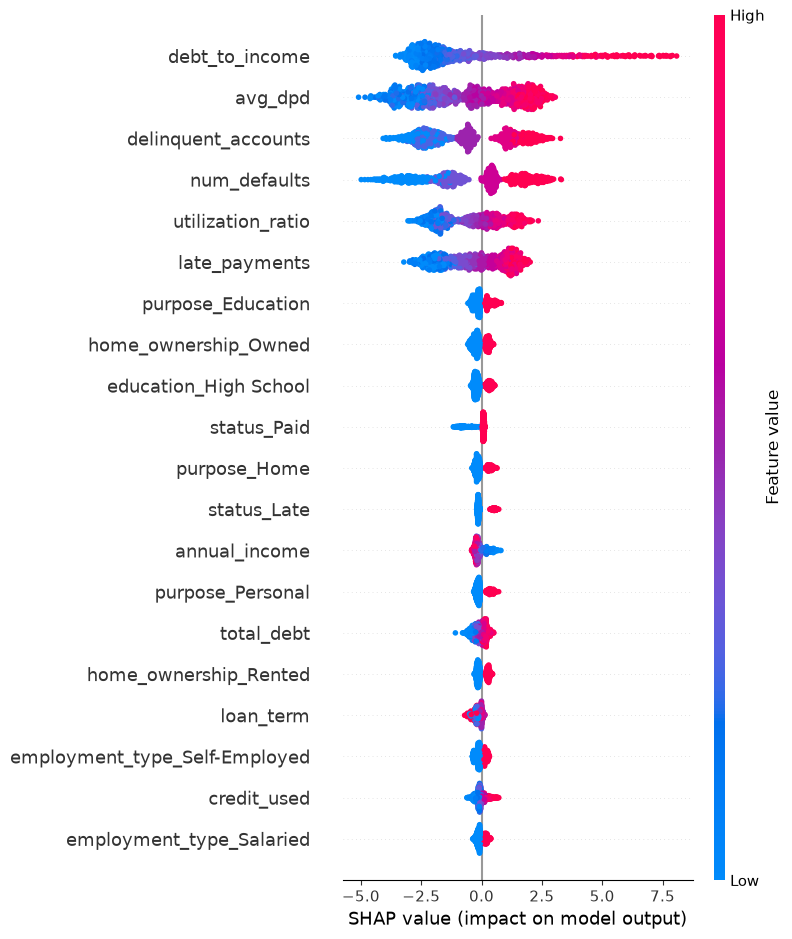

In [38]:
shap.summary_plot(
    shap_values,
    X_test
)

In [39]:
print(X.columns.tolist())

['id', 'age', 'annual_income', 'loan_amount', 'loan_term', 'dependents', 'bureau_score', 'num_of_accounts', 'num_of_open_accounts', 'total_debt', 'delinquent_accounts', 'num_loans', 'num_defaults', 'total_loan_amount', 'total_repaid_amount', 'avg_dpd', 'months_on_book', 'dpd', 'payment_amount', 'num_cards', 'credit_limit', 'utilization_ratio', 'max_utilization_ratio', 'late_payments', 'debt_to_income', 'loan_to_income', 'repayment_ratio', 'credit_used', 'gender_Male', 'education_Diploma', 'education_High School', 'education_Master', 'employment_type_Salaried', 'employment_type_Self-Employed', 'purpose_Education', 'purpose_Home', 'purpose_Personal', 'home_ownership_Owned', 'home_ownership_Rented', 'status_Late', 'status_Paid']


In [40]:
X = df.drop(
    ["id", "default_12m"],
    axis=1
)

y = df["default_12m"]

print(X.shape)

(5000, 40)


In [41]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "data/models/feature_columns.pkl"
)

print("Feature Columns Saved")

Feature Columns Saved


In [42]:
import joblib

features = joblib.load(
    "data/models/feature_columns.pkl"
)

print(features)

['age', 'annual_income', 'loan_amount', 'loan_term', 'dependents', 'bureau_score', 'num_of_accounts', 'num_of_open_accounts', 'total_debt', 'delinquent_accounts', 'num_loans', 'num_defaults', 'total_loan_amount', 'total_repaid_amount', 'avg_dpd', 'months_on_book', 'dpd', 'payment_amount', 'num_cards', 'credit_limit', 'utilization_ratio', 'max_utilization_ratio', 'late_payments', 'debt_to_income', 'loan_to_income', 'repayment_ratio', 'credit_used', 'gender_Male', 'education_Diploma', 'education_High School', 'education_Master', 'employment_type_Salaried', 'employment_type_Self-Employed', 'purpose_Education', 'purpose_Home', 'purpose_Personal', 'home_ownership_Owned', 'home_ownership_Rented', 'status_Late', 'status_Paid']


In [43]:
import joblib

model = joblib.load(
    "data/models/credit_risk_xgboost.pkl"
)

print(model.n_features_in_)

41


In [44]:
X = df.drop(
    ["id", "default_12m"],
    axis=1
)

y = df["default_12m"]

print(X.shape)

(5000, 40)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
print(xgb.n_features_in_)

40


In [49]:
import joblib

joblib.dump(
    xgb,
    "data/models/credit_risk_xgboost.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "data/models/feature_columns.pkl"
)

print("Everything Saved Successfully")

Everything Saved Successfully


In [50]:
model = joblib.load(
    "data/models/credit_risk_xgboost.pkl"
)

print(model.n_features_in_)

40


In [51]:
feature_importance.head(10)

,Feature,Importance
24,debt_to_income,0.148624
15,avg_dpd,0.097943
2,annual_income,0.084848
12,num_defaults,0.068556
10,delinquent_accounts,0.062683
9,total_debt,0.052307
21,utilization_ratio,0.047189
25,loan_to_income,0.044495
23,late_payments,0.037670
27,credit_used,0.025368


In [52]:
dir()

['GridSearchCV',
 'In',
 'LogisticRegression',
 'Out',
 'RandomForestClassifier',
 'SMOTE',
 'X',
 'XGBClassifier',
 'X_test',
 'X_train',
 'X_train_smote',
 '_',
 '_10',
 '_17',
 '_26',
 '_31',
 '_47',
 '_51',
 '_7',
 '_8',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'app',
 'bureau',
 'categorical_cols',
 'credit',
 'cross_val_score',
 'df',
 'exit',
 'explainer',
 

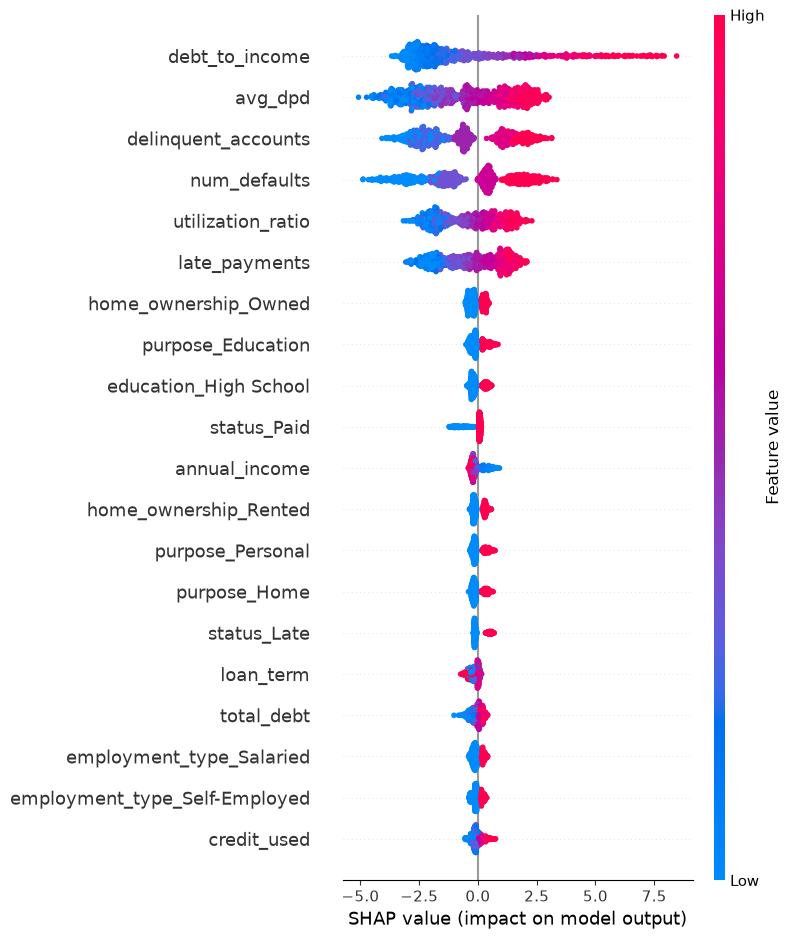

In [53]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

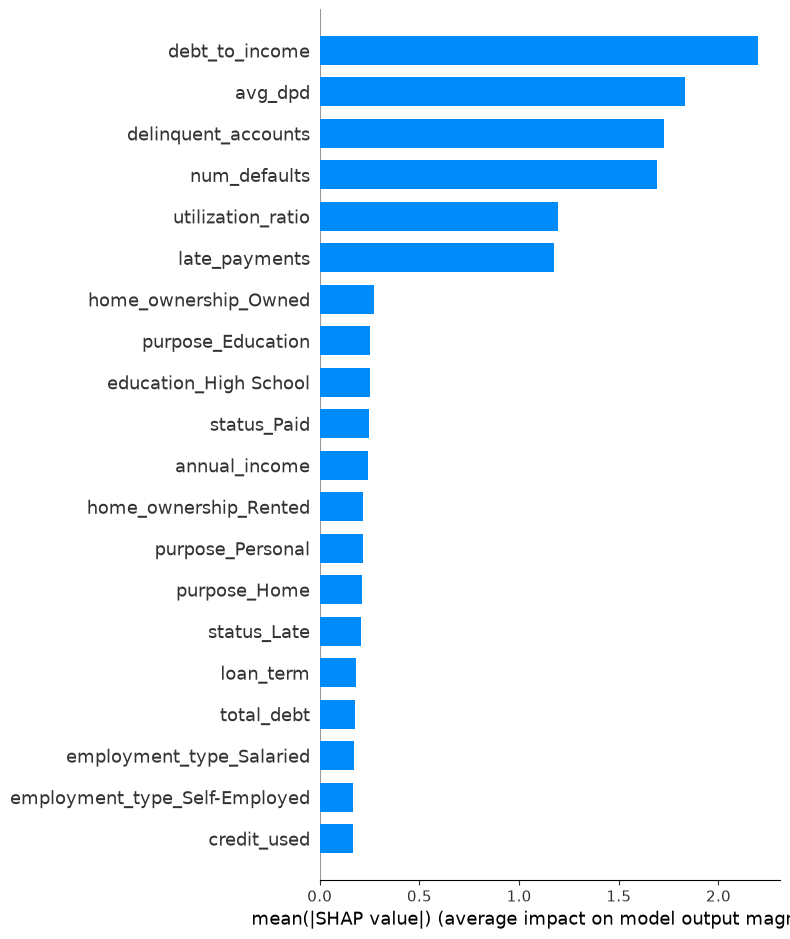

In [54]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

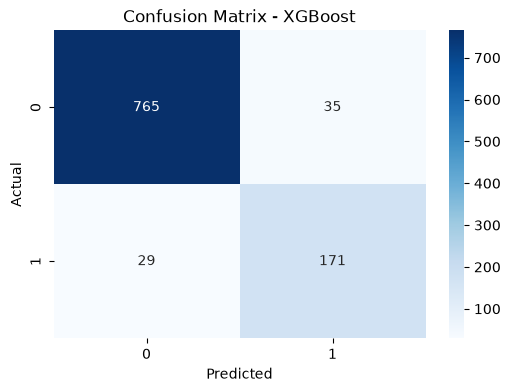

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()